# 회귀 알고리즘 / 규제
## k-최근접 이웃 회귀
회귀를 이용하여 농어의 몸무게 구하기!
### 지도학습
지도학습 알고리즘은 크게 아래 두가지 유형으로 나뉜다.
- 분류
- 회귀
이 중에서 회귀는 클래스 중 하나로 분류하는 것이 아니라, **임의의 어떤 숫자를 예측하는 것**

이전 스터디에서 농어와 빙어, 각 물고기들의 특징(몸무게, 길이)을 이용하여 임의의 몸무게와 임의의 길이를 가진 물고기가 농어, 빙어 두가지 클래스 중 어느 클래스에 속하는지 _분류_ 하였다.
즉, 클래스를 _고르는_ 문제를 해결한 것

그렇다면 물고기의 특징 ( 길이, 두께, 높이 등 )을 이용해서 몸무게를 예측하려면? 즉, 0,1 분류가 아니라 연속적인 어떤 수를 예측하려면 어떻게 해야하는가?

-> 회귀문제

**회귀**는 내년의 경제 성장률 예측, 배달이 언제 올지 예측 등 이런 문제들..
**정해진 클래스가 없고 임의의 수치를 출력해낸다.**

정리하자면

>회귀 : 두 변수 사이의 상관관계를 분석하는 방법

---

## k-최근접 이웃 알고리즘은 회귀에도 동작한다!
### k-최근접 알고리즘이 분류와 회귀에 적용되는 방식 비교

#### k-최근접 이웃 _**분류**_ 알고리즘
: 예측하려는 샘플에 가장 가까운 k개의 샘플을 골라서, 그 k개의 샘플들의 클래스를 확인하여 다수클래스를 새로운 예측하려는 샘플의 클래스로 예측한다.

#### k-최근접 이웃 _**회귀**_ 알고리즘
: 예측하려는 샘플에 가장 가까운 k개 샘플 고른다. 분류와 다르게 회귀는 어떤 클래스를 예측하는 것이 아니라, **임의의 수치**를 예측하는 것<br>
어떤 수를 예측하는 가장 쉬운 방법은? -> 평균 구하기

즉 가장 가까운 k개의 샘플들의 타겟값이 90,100,80이라고 가정하면 예측하려는 샘플의 예측 타겟값은 90+100+80/3 이 된다

---

## 데이터 준비
농어의 몸무게를 구할것이기 때문에 타겟값은 몸무게, 특성은 길이

In [2]:
import numpy as np

# 넘파이의 array() 메소드 이용하여 넘파이 배열 생성
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )


---

#### 데이터 특성을 알아보기 위해서 시각화하기

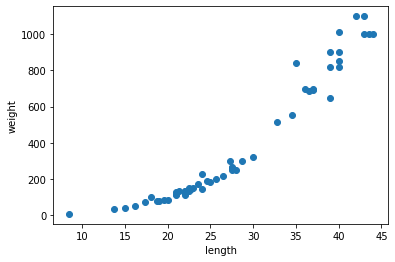

In [3]:
import matplotlib.pyplot as plt

# 산점도 사용 x축은 길이, y축은 무게
plt.scatter(perch_length, perch_weight)

# x,y축 내용표시
plt.xlabel('length')
plt.ylabel('weight')

# 산점도 객체 화면 출력
plt.show()

---
#### 머신러닝 전 테스트 세트, 훈련세트 나누기
사이킷런 활용

In [4]:
from sklearn.model_selection import train_test_split

# train_test_split(X, Y) => X는 독립변수, Y는 종속변수, 훈련세트와 테스트세트 비율은 
# 디폴트 0.25
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

---

#### 머신러닝 모델 생성, 훈련, 평가

In [5]:
from sklearn.neighbors import KNeighborsRegressor

# k-최근접 이웃 회귀 모델 생성
knr = KNeighborsRegressor()
# k-최근접 이웃 회귀 모델 훈련
knr.fit(train_input, train_target)
# k-최근접 이웃 회귀 모델 평가
knr.score(test_input, test_target)

0.992809406101064

#### score의 의미?
이전 스터디에서 ( k-nn 분류 ) score는 테스트 샘플을 얼마나 정확하게 분류했는지를 나타냈음 (0.5면 반만 맞춘것, 1이면 다 맞춘것 ... )

그러나 회귀는 임의의 수치를 예측해내기 때문에 정확하게 맞추는 것은 불가능하다.<br>
따라서 회귀를 평가하는 값은 $R^2$(결정계수)라고 부른다.

### 결정계수 $R^2$

$$
R^2 = 1 - \frac{\sum(타겟 - 예측)^2}{\sum(타겟 - 평균)^2}
$$

> 1에 가까울수록 좋은 값이다!

In [6]:
from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_input)
# mae : 타겟과 예측값의 절대값 오차를 평균
mae = mean_absolute_error(test_target, test_prediction)
print(mae)


19.157142857142862


---

## 과대적합, 과소적합

- 과대적합 
    - 훈련세트 점수는 좋지만 테스트 세트 점수가 나쁜 경우
    - 훈련세트에만 잘 맞는 모델
    - 실전에 투입하면 잘 동작하지 않는다
- 과소적합
    - 훈련세트 점수보다 테스트 점수 세트가 높거나 두 점수 모두 너무 낮은 경우
    - 모델이 너무 단순해서 적절히 훈련이 진행되지 않은 경우
    - 훈련세트와 테스트 세트의 크기가 너무 작은 경우 발생
    
과소적합을 해결하기 위해서 모델을 더 복잡하게 만들어준다. ( 훈련세트에 더 적합하게 )

In [7]:
print(knr.score(train_input, train_target))

0.9698823289099254


In [8]:
# 이웃 개수 3으로 조정
knr.n_neighbors = 3

# 재훈련
knr.fit(train_input, train_target)
print("훈련세트 평가: ",knr.score(train_input, train_target))

print("테스트세트 평가: ",knr.score(test_input, test_target))

훈련세트 평가:  0.9804899950518966
테스트세트 평가:  0.9746459963987609
